# STEP 8. 예측 모델 + 시간 분할 검증

**핵심 질문**은 예측 질문입니다 — *자치구별 다음 분기 순감소로 전환될 요식업 업종은 무엇인가?*

STEP 6·7 이 **왜**를 답했다면 여기서는 **무엇을**을 답할 준비를 합니다.

## 시간 분할

| 용도 | 피처 분기 | 타깃 분기 | 라벨 |
|---|---|---|---|
| 학습 | `TRAIN_QUARTERS` 20231~20253 | 20232~20254 | 있음 |
| 검증 | `VALID_Q` 20254 | **20261** | 있음 |
| 예측 | `SCORE_Q` 20261 | **20262** | 없음 (STEP 9) |

검증 세트는 20261 의 **실제** 개업·폐업으로 채점하므로 진짜 미래 예측을 흉내낸 평가입니다.

## 평가 지표를 정확도로 쓰지 않는 이유

양성률이 25% 입니다. **"전부 순감소 아님"이라고만 찍어도 정확도 75%** 가 나옵니다. 그래서 아래를 씁니다.

| 지표 | 의미 | 기준 |
|---|---|---|
| **AUC** | 무작위로 뽑은 양성이 음성보다 높은 점수를 받을 확률 | 0.5 = 무작위, 0.7 = 쓸만함 |
| **PR-AUC** | 양성 위주 성능. **양성률(0.26)이 무작위 기준선** | 기준선 대비 얼마나 높은가 |
| **Brier** | 확률 예측의 평균제곱오차 | **낮을수록 좋음** |
| **보정(calibration)** | "30% 라고 한 칸들이 실제로 30% 인가" | 순위를 매기려면 필수 |

## 절차

8-1 분할·누수 점검 → 8-2 피처 → 8-3 베이스라인 → 8-4 모델 → 8-5 롤링 오리진 → 8-6 보정 → **8-7 어느 단위까지 믿을 수 있나** → 8-8 변수 중요도 → 8-10 저장


In [1]:
import sys, os
from pathlib import Path

# 노트북이 어디서 열리든 프로젝트 루트를 찾아 sys.path에 추가
ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

# config.py 를 고친 뒤 커널을 재시작하지 않으면 파이썬이 옛 모듈을 캐시한다.
import importlib
if "config" in sys.modules:
    importlib.reload(sys.modules["config"])

import numpy as np
import pandas as pd
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
print("프로젝트 루트:", ROOT)

프로젝트 루트: c:\Users\spide\ai-data-bootcamp\project\h2_nb


In [2]:
import pickle
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, log_loss, roc_curve)
from config import (PROC, FIG, TARGET_TYPE, TRAIN_QUARTERS, VALID_Q, SCORE_Q,
                    ROLLING_VALID, PRED_NUM, build_features, design_matrix,
                    set_korean_font)
set_korean_font()
OUT = FIG.parent
SEED = 42

panel = build_features(pd.read_pickle(PROC / "03_panel.pkl"))
print(f"패널 {panel.shape}")
print(f"학습 분기 {TRAIN_QUARTERS[0]}~{TRAIN_QUARTERS[-1]} ({len(TRAIN_QUARTERS)}개)")
print(f"검증 분기 {VALID_Q} (타깃 {SCORE_Q})")

패널 (67475, 42)
학습 분기 20231~20253 (11개)
검증 분기 20254 (타깃 20261)


## 8-1. 분할과 누수 점검

누수는 조용히 일어나고 결과를 좋아 보이게 만듭니다. 그래서 코드로 막습니다.

In [3]:
tr = panel[panel["기준_년분기_코드"].isin(TRAIN_QUARTERS)].copy()
va = panel[panel["기준_년분기_코드"] == VALID_Q].copy()

assert VALID_Q not in TRAIN_QUARTERS,           "검증 분기가 학습 목록에 있습니다"
assert tr["기준_년분기_코드"].max() < VALID_Q,   "학습에 검증 분기 이후가 섞였습니다"
assert len(tr) + len(va) == len(panel),         "분할 합이 전체와 다릅니다"
print("✅ 누수 점검 통과")
print(f"  학습 {len(tr):,}행  양성률 {tr['y'].mean():.1%}")
print(f"  검증 {len(va):,}행  양성률 {va['y'].mean():.1%}")
print(f"\n※ 양성률이 학습과 검증에서 비슷해야 분포 이동이 없다고 볼 수 있습니다.")

✅ 누수 점검 통과
  학습 61,996행  양성률 25.4%
  검증 5,479행  양성률 26.0%

※ 양성률이 학습과 검증에서 비슷해야 분포 이동이 없다고 볼 수 있습니다.


## 8-2. 피처

`config.build_features` / `config.design_matrix` 를 씁니다. **STEP 9 가 같은 함수를 호출하므로 학습과 예측이 어긋날 수 없습니다.**

### 분기 더미를 넣지 않는 이유

STEP 6·7 의 성향점수·설명 모형에는 분기 더미를 넣었습니다. 그건 **설명**이라 학습 분기 안에서만 쓰면 됐기 때문입니다.

예측은 다릅니다. 예측 대상은 20261 인데 학습에 없는 분기라 더미를 만들 수 없고, 만들어도 전부 0 이 됩니다. **미래 분기의 계절 효과는 알 수 없다**는 게 정직한 태도입니다.

### 새로 넣은 것 — 현재 모멘텀

`개업률`, `폐업률`, `순증감률`, `순감소_현재` 는 **피처 분기 시점의 값**이라 누수가 아닙니다. "지금 이미 줄고 있는 칸이 다음 분기에도 줄 확률"을 모형이 쓸 수 있게 합니다.

In [4]:
Xtr = design_matrix(tr)
COLS = list(Xtr.columns)
Xva  = design_matrix(va, COLS)
ytr, yva = tr["y"].to_numpy(), va["y"].to_numpy()

MED = Xtr.median()                     # 선형모형용 결측 대치값 (학습에서만 계산)
Xtr_i, Xva_i = Xtr.fillna(MED), Xva.fillna(MED)

print(f"피처 {len(COLS)}개 = 수치 {len(PRED_NUM)} + 더미 {len(COLS)-len(PRED_NUM)}")
print(f"  결측 있는 피처 : {[c for c in COLS if Xtr[c].isna().any()]}")
print(f"\n검증 설계행렬 컬럼 일치 : {list(Xva.columns) == COLS}")

피처 51개 = 수치 12 + 더미 39
  결측 있는 피처 : ['log_점포당매출']

검증 설계행렬 컬럼 일치 : True


## 8-3. 베이스라인

**모델이 좋은지는 베이스라인과 비교해야 압니다.** 세 가지를 놓습니다.

| | 규칙 |
|---|---|
| A | 항상 학습 평균 확률 (아무 정보도 안 씀) |
| B | 직전 분기 상태 그대로 (지금 줄고 있으면 다음에도 줄 것) |
| C | 업종별 학습 기간 평균 순감소율 |

In [5]:
def evaluate(name, p, y=yva):
    return {"모형": name,
            "AUC": roc_auc_score(y, p),
            "PR-AUC": average_precision_score(y, p),
            "Brier": brier_score_loss(y, p),
            "LogLoss": log_loss(y, np.clip(p, 1e-6, 1-1e-6))}

rows = [
    evaluate("A 항상 평균",   np.full(len(yva), ytr.mean())),
    evaluate("B 직전분기 상태", np.where(va["순감소_현재"] == 1, 0.60, 0.15)),
    evaluate("C 업종 평균",   va["서비스_업종_코드_명"]
                              .map(tr.groupby("서비스_업종_코드_명")["y"].mean()).to_numpy()),
]
display(pd.DataFrame(rows).round(4))
print(f"※ PR-AUC 의 무작위 기준선 = 검증 양성률 {yva.mean():.4f}")

,모형,AUC,PR-AUC,Brier,LogLoss
0,A 항상 평균,0.5000,0.2597,0.1923,0.5728
1,B 직전분기 상태,0.5315,0.2742,0.2178,0.6336
2,C 업종 평균,0.5543,0.2910,0.1912,0.5699


※ PR-AUC 의 무작위 기준선 = 검증 양성률 0.2597


## 8-4. 모델

- **로지스틱** — 선형. 해석 쉽고 확률이 잘 보정되는 편
- **부스팅**(HistGradientBoosting) — 비선형·상호작용을 잡음. 결측을 그대로 처리
- **랜덤포레스트** — 비교용

In [6]:
logit = make_pipeline(StandardScaler(),
                      LogisticRegression(max_iter=3000, C=1.0, random_state=SEED))
logit.fit(Xtr_i, ytr)

hgb = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.06, max_leaf_nodes=31,
    l2_regularization=1.0, random_state=SEED).fit(Xtr, ytr)

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                            n_jobs=-1, random_state=SEED).fit(Xtr_i, ytr)

preds = {"D 로지스틱": logit.predict_proba(Xva_i)[:, 1],
         "E 부스팅":   hgb.predict_proba(Xva)[:, 1],
         "F 랜덤포레스트": rf.predict_proba(Xva_i)[:, 1]}
rows += [evaluate(k, v) for k, v in preds.items()]

board = pd.DataFrame(rows).set_index("모형")
display(board.round(4))

BEST = board["PR-AUC"].idxmax()
print(f"→ PR-AUC 기준 최고 : {BEST}")
print(f"   베이스라인 대비 PR-AUC {board.loc[BEST,'PR-AUC']:.3f} vs {yva.mean():.3f} "
      f"({board.loc[BEST,'PR-AUC']/yva.mean():.2f}배)")

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


,AUC,PR-AUC,Brier,LogLoss
모형,,,,
A 항상 평균,0.5000,0.2597,0.1923,0.5728
B 직전분기 상태,0.5315,0.2742,0.2178,0.6336
C 업종 평균,0.5543,0.2910,0.1912,0.5699
D 로지스틱,0.6695,0.4067,0.1796,0.5400
E 부스팅,0.6687,0.4179,0.1789,0.5389
F 랜덤포레스트,0.6625,0.4125,0.1798,0.5411


→ PR-AUC 기준 최고 : E 부스팅
   베이스라인 대비 PR-AUC 0.418 vs 0.260 (1.61배)


## 8-5. 롤링 오리진 검증

검증 분기가 하나뿐이면 그 분기가 유난히 쉬웠거나 어려웠을 수 있습니다. **학습 종료 분기를 밀어가며 여러 번 검증**해 성능이 얼마나 흔들리는지 봅니다.

각 반복에서 학습은 **검증 분기 이전만** 씁니다 — 미래를 보지 않습니다.

In [7]:
roll = []
oof  = []                     # 각 분기의 out-of-fold 예측 (8-7 에서 사용)
for v in ROLLING_VALID:
    tr_v = panel[panel["기준_년분기_코드"] < v]
    va_v = panel[panel["기준_년분기_코드"] == v]
    Xt = design_matrix(tr_v); C = list(Xt.columns)
    Xv = design_matrix(va_v, C)

    m = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.06,
                                       max_leaf_nodes=31, l2_regularization=1.0,
                                       random_state=SEED).fit(Xt, tr_v["y"])
    p = m.predict_proba(Xv)[:, 1]

    l = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, random_state=SEED))
    l.fit(Xt.fillna(Xt.median()), tr_v["y"])
    pl = l.predict_proba(Xv.fillna(Xt.median()))[:, 1]

    roll.append({"검증분기": v, "학습n": len(tr_v), "검증n": len(va_v),
                 "양성률": va_v["y"].mean(),
                 "AUC_부스팅": roc_auc_score(va_v["y"], p),
                 "AUC_로지스틱": roc_auc_score(va_v["y"], pl),
                 "PR-AUC_부스팅": average_precision_score(va_v["y"], p),
                 "Brier_부스팅": brier_score_loss(va_v["y"], p)})
    o = va_v[["기준_년분기_코드", "자치구", "서비스_업종_코드_명",
              "상권유형", "상권_코드", "y"]].copy()
    o["p"] = p
    oof.append(o)

oof = pd.concat(oof, ignore_index=True)
rollf = pd.DataFrame(roll)
display(rollf.round(4))
print(f"AUC(부스팅) 평균 {rollf['AUC_부스팅'].mean():.4f}  표준편차 {rollf['AUC_부스팅'].std():.4f}")
print(f"→ 표준편차가 작으면 분기가 달라져도 성능이 안정적이라는 뜻입니다.")
print(f"OOF 예측 누적 {len(oof):,}행 ({len(ROLLING_VALID)}개 분기)")

,검증분기,학습n,검증n,양성률,AUC_부스팅,AUC_로지스틱,PR-AUC_부스팅,Brier_부스팅
0,20243,34252,5622,0.2622,0.6516,0.6606,0.3871,0.1834
1,20244,39874,5586,0.2836,0.6743,0.6701,0.4453,0.1905
2,20251,45460,5534,0.2615,0.6533,0.6451,0.3958,0.1821
3,20252,50994,5502,0.2597,0.6708,0.6676,0.4206,0.1788
4,20253,56496,5500,0.2531,0.6768,0.6742,0.4121,0.1753
5,20254,61996,5479,0.2597,0.6687,0.6695,0.4179,0.1789


AUC(부스팅) 평균 0.6659  표준편차 0.0108
→ 표준편차가 작으면 분기가 달라져도 성능이 안정적이라는 뜻입니다.
OOF 예측 누적 33,223행 (6개 분기)


## 8-6. 확률 보정

자치구별로 업종 순위를 매기려면 **확률값 자체가 믿을 만해야** 합니다. "35%"라고 한 칸들이 실제로 35% 근처에서 순감소해야 합니다.

예측 확률을 10분위로 나눠 각 구간의 평균 예측값과 실제 발생률을 비교합니다. **두 값이 가까울수록 잘 보정된 것**입니다.

In [8]:
p_best = preds[BEST]
q = pd.qcut(p_best, 10, labels=False, duplicates="drop")
cal = (pd.DataFrame({"예측확률": p_best, "실제": yva, "분위": q})
       .groupby("분위").agg(칸수=("실제", "size"), 평균예측=("예측확률", "mean"),
                            실제발생률=("실제", "mean")))
cal["차이"] = cal["실제발생률"] - cal["평균예측"]
display(cal.round(3))
print(f"최대 절대 오차 {cal['차이'].abs().max():.3f}")
print("※ 0.05 이내면 순위 매기기에 쓸 만합니다. 한쪽으로 계속 치우치면 보정이 필요합니다.")

,칸수,평균예측,실제발생률,차이
분위,,,,
0,548,0.113,0.139,0.026
1,548,0.140,0.135,-0.005
2,548,0.167,0.141,-0.027
3,548,0.195,0.177,-0.018
4,548,0.223,0.245,0.021
5,547,0.256,0.218,-0.038
6,548,0.286,0.307,0.021
7,548,0.314,0.361,0.047
8,548,0.356,0.385,0.029


최대 절대 오차 0.048
※ 0.05 이내면 순위 매기기에 쓸 만합니다. 한쪽으로 계속 치우치면 보정이 필요합니다.


## 8-7. 어느 단위까지 믿을 수 있나 ★

이 단계에서 제일 중요한 절입니다.

STEP 9 는 **자치구 × 업종** 표를 만들 예정입니다. 그런데 그 단위에서 예측이 맞는지 확인하려면 **비교 대상인 "실제 값"부터 믿을 만해야** 합니다.

그래서 먼저 **목표 자체의 신뢰도**를 잽니다. 같은 칸의 관측치를 무작위로 반씩 나눠 각각 순감소율을 계산하고, 두 절반의 순위가 서로 얼마나 일치하는지 봅니다(**반분 신뢰도**). 같은 데이터를 쪼갠 것뿐이니 이 값이 낮다면 **그 단위의 관측값은 사실상 잡음**입니다.

In [9]:
def split_half(frame, keys, min_n=0, B=200, seed=SEED):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(B):
        f = frame.copy()
        f["h"] = rng.integers(0, 2, len(f))
        c = f.groupby(keys + ["h"])["y"].agg(["mean", "size"]).reset_index()
        pv = c.pivot_table(index=keys, columns="h", values=["mean", "size"]).dropna()
        if min_n:
            pv = pv[(pv[("size", 0)] >= min_n/2) & (pv[("size", 1)] >= min_n/2)]
        if len(pv) >= 3:
            out.append(spearmanr(pv[("mean", 0)], pv[("mean", 1)]).statistic)
    return np.nanmean(out) if out else np.nan

gm_va = va[va["상권유형"] == TARGET_TYPE]
print(f"[단일 분기 {VALID_Q}, {TARGET_TYPE} n={len(gm_va):,}] 목표값의 반분 신뢰도")
for nm, keys in [("업종", ["서비스_업종_코드_명"]),
                 ("자치구", ["자치구"]),
                 ("자치구×업종", ["자치구", "서비스_업종_코드_명"])]:
    sz = gm_va.groupby(keys).size()
    print(f"  {nm:12} 칸 {len(sz):3d}개 · 칸당 중앙 {int(sz.median()):4d}행 "
          f"→ 반분 신뢰도 {split_half(gm_va, keys):+.3f}")
print("\n※ 반분 신뢰도가 0 근처면 '실제 값'조차 재보면 순위가 뒤바뀐다는 뜻입니다.")
print("   그 단위에서는 단일 분기로 모형을 평가하는 것 자체가 불가능합니다.")

[단일 분기 20254, 골목상권 n=2,772] 목표값의 반분 신뢰도
  업종           칸  10개 · 칸당 중앙  138행 → 반분 신뢰도 +0.212
  자치구          칸  25개 · 칸당 중앙  119행 → 반분 신뢰도 +0.086
  자치구×업종       칸 240개 · 칸당 중앙    7행 → 반분 신뢰도 +0.035

※ 반분 신뢰도가 0 근처면 '실제 값'조차 재보면 순위가 뒤바뀐다는 뜻입니다.
   그 단위에서는 단일 분기로 모형을 평가하는 것 자체가 불가능합니다.


### 여러 분기를 모으면 달라집니다

8-5 에서 쌓은 **out-of-fold 예측**(각 분기를 그 이전 데이터로만 예측한 값)을 6개 분기치 모으면 칸당 표본이 6배가 됩니다. 이제 목표값도 안정되고 평가가 가능해집니다.

In [10]:
gm_oof = oof[oof["상권유형"] == TARGET_TYPE]
print(f"OOF {TARGET_TYPE} {len(gm_oof):,}행 ({len(ROLLING_VALID)}개 분기)\n")

rows_lv = []
for nm, keys, min_n in [("업종", ["서비스_업종_코드_명"], 0),
                        ("자치구", ["자치구"], 0),
                        ("자치구×업종", ["자치구", "서비스_업종_코드_명"], 60)]:
    c = (gm_oof.groupby(keys)
         .agg(예측=("p", "mean"), 실제=("y", "mean"), n=("y", "size")).reset_index())
    c = c[c["n"] >= min_n]
    rows_lv.append({"단위": nm, "칸수": len(c), "칸당_중앙표본": int(c["n"].median()),
                    "예측↔실제_순위상관": spearmanr(c["예측"], c["실제"]).statistic,
                    "목표_반분신뢰도": split_half(gm_oof, keys, min_n)})
display(pd.DataFrame(rows_lv).round(3))
print("※ 순위상관이 목표 반분신뢰도보다 높으면, 모형이 '잡음 낀 관측값'보다")
print("   오히려 그 칸의 참값에 가깝다는 뜻입니다.")

OOF 골목상권 16,913행 (6개 분기)



,단위,칸수,칸당_중앙표본,예측↔실제_순위상관,목표_반분신뢰도
0,업종,10,844,0.855,0.617
1,자치구,25,699,0.805,0.537
2,자치구×업종,97,123,0.546,0.259


※ 순위상관이 목표 반분신뢰도보다 높으면, 모형이 '잡음 낀 관측값'보다
   오히려 그 칸의 참값에 가깝다는 뜻입니다.


In [11]:
# 자치구별 최고 위험 업종 top-1 적중 (OOF 풀링 기준)
cell = (gm_oof.groupby(["자치구", "서비스_업종_코드_명"])
        .agg(예측=("p", "mean"), 실제=("y", "mean"), n=("y", "size")).reset_index())
cell = cell[cell["n"] >= 60]

hits, sizes = [], []
for gu, s in cell.groupby("자치구"):
    if len(s) < 3:
        continue
    hits.append(s.sort_values("예측", ascending=False).iloc[0]["서비스_업종_코드_명"]
                == s.sort_values("실제", ascending=False).iloc[0]["서비스_업종_코드_명"])
    sizes.append(len(s))
chance = np.mean([1/x for x in sizes])
print(f"자치구 {len(hits)}개 (업종 3종 이상, 칸 60행 이상)")
print(f"  top-1 적중률 {np.mean(hits):.1%}   무작위 기준 {chance:.1%}")
print("\n→ 1위 하나만 콕 집는 것은 어렵습니다. STEP 9 는 '1위 업종'을 단정하지 말고")
print("   확률과 표본 수를 함께 실은 순위표로 제시해야 합니다.")

자치구 20개 (업종 3종 이상, 칸 60행 이상)
  top-1 적중률 45.0%   무작위 기준 24.1%

→ 1위 하나만 콕 집는 것은 어렵습니다. STEP 9 는 '1위 업종'을 단정하지 말고
   확률과 표본 수를 함께 실은 순위표로 제시해야 합니다.


## 8-8. 변수 중요도

**순열 중요도(permutation importance)** — 한 변수의 값을 무작위로 섞었을 때 성능이 얼마나 떨어지는지 봅니다. 많이 떨어질수록 중요한 변수입니다. 모형 내부 구조와 무관하게 잴 수 있어 공정합니다.

In [11]:
model_best = {"D 로지스틱": logit, "E 부스팅": hgb, "F 랜덤포레스트": rf}[BEST]
X_use = Xva if BEST == "E 부스팅" else Xva_i

pi = permutation_importance(model_best, X_use, yva, scoring="roc_auc",
                            n_repeats=5, random_state=SEED, n_jobs=-1)
imp = (pd.DataFrame({"변수": COLS, "AUC 감소": pi.importances_mean,
                     "표준편차": pi.importances_std})
       .sort_values("AUC 감소", ascending=False))
display(imp.head(15).round(4))
print("※ 값이 0 이하인 변수는 빼도 성능이 안 떨어집니다.")

,변수,AUC 감소,표준편차
0,log_점포수,0.1625,0.0037
10,log_점포당매출,0.0062,0.0025
8,순증감률,0.0050,0.0016
21,svc_호프-간이주점,0.0037,0.0005
20,svc_한식음식점,0.0020,0.0013
6,개업률,0.0018,0.0009
2,log_면적,0.0010,0.0004
18,svc_커피-음료,0.0010,0.0007
7,폐업률,0.0007,0.0003
1,log_유동인구,0.0005,0.0008


※ 값이 0 이하인 변수는 빼도 성능이 안 떨어집니다.


## 8-9. 시각화

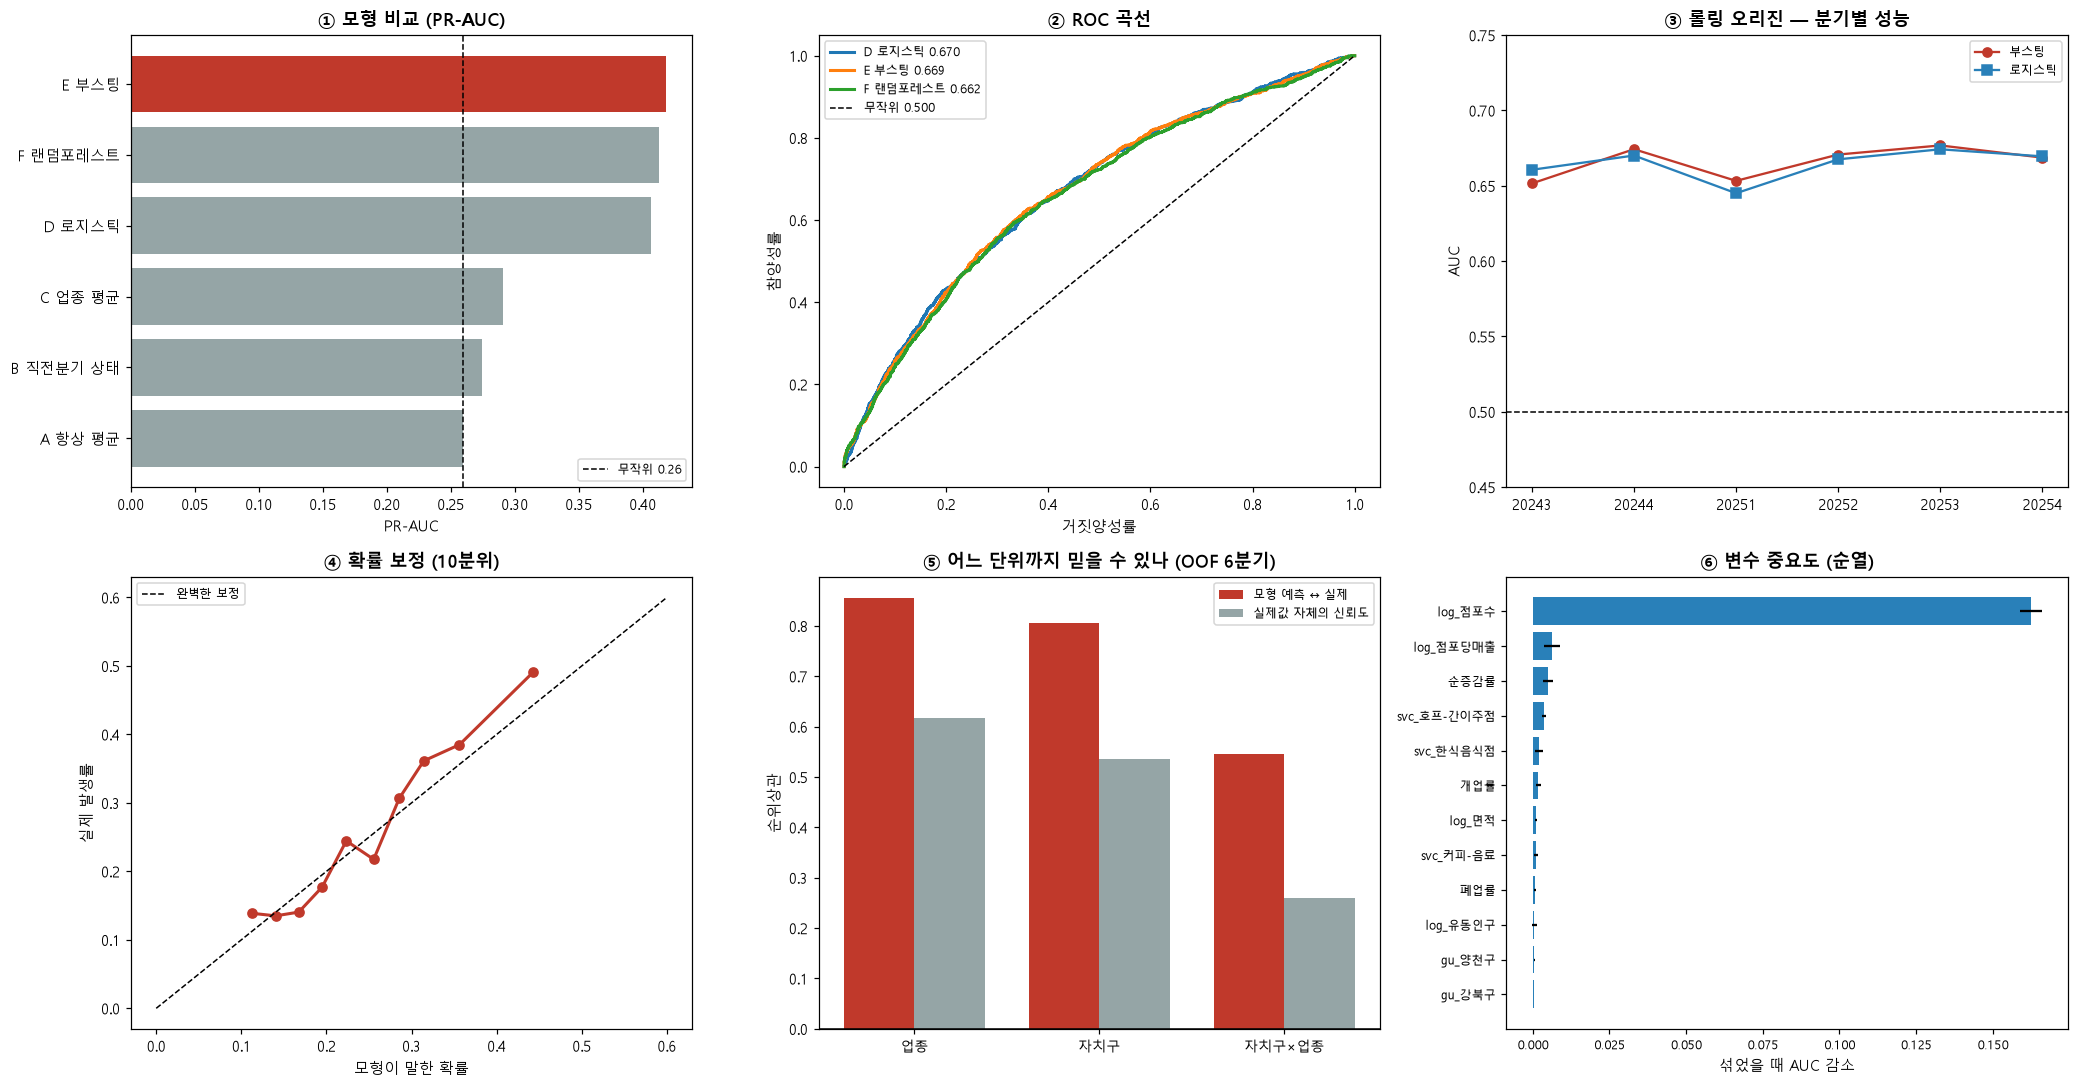

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(19, 10))

# ① 모형 비교
b = board.sort_values("PR-AUC")
cols = ["#c0392b" if i == BEST else "#95a5a6" for i in b.index]
ax[0,0].barh(b.index, b["PR-AUC"], color=cols)
ax[0,0].axvline(yva.mean(), ls="--", c="k", lw=1, label=f"무작위 {yva.mean():.2f}")
ax[0,0].set_xlabel("PR-AUC"); ax[0,0].legend(fontsize=8)
ax[0,0].set_title("① 모형 비교 (PR-AUC)", weight="bold")

# ② ROC
for nm, p in preds.items():
    fpr, tpr, _ = roc_curve(yva, p)
    ax[0,1].plot(fpr, tpr, lw=2, label=f"{nm} {roc_auc_score(yva,p):.3f}")
ax[0,1].plot([0,1],[0,1], ls="--", c="k", lw=1, label="무작위 0.500")
ax[0,1].set_xlabel("거짓양성률"); ax[0,1].set_ylabel("참양성률")
ax[0,1].set_title("② ROC 곡선", weight="bold"); ax[0,1].legend(fontsize=8)

# ③ 롤링 오리진
ax[0,2].plot(rollf["검증분기"].astype(str), rollf["AUC_부스팅"], marker="o", label="부스팅", color="#c0392b")
ax[0,2].plot(rollf["검증분기"].astype(str), rollf["AUC_로지스틱"], marker="s", label="로지스틱", color="#2980b9")
ax[0,2].axhline(0.5, ls="--", c="k", lw=1)
ax[0,2].set_ylim(0.45, 0.75); ax[0,2].set_ylabel("AUC")
ax[0,2].set_title("③ 롤링 오리진 — 분기별 성능", weight="bold"); ax[0,2].legend(fontsize=8)

# ④ 보정
ax[1,0].plot(cal["평균예측"], cal["실제발생률"], marker="o", color="#c0392b", lw=2)
ax[1,0].plot([0,0.6],[0,0.6], ls="--", c="k", lw=1, label="완벽한 보정")
ax[1,0].set_xlabel("모형이 말한 확률"); ax[1,0].set_ylabel("실제 발생률")
ax[1,0].set_title("④ 확률 보정 (10분위)", weight="bold"); ax[1,0].legend(fontsize=8)

# ⑤ 신뢰 가능한 단위
lv = pd.DataFrame(rows_lv)
x = np.arange(len(lv)); w = 0.38
ax[1,1].bar(x - w/2, lv["예측↔실제_순위상관"], w, label="모형 예측 ↔ 실제", color="#c0392b")
ax[1,1].bar(x + w/2, lv["목표_반분신뢰도"], w, label="실제값 자체의 신뢰도", color="#95a5a6")
ax[1,1].set_xticks(x); ax[1,1].set_xticklabels(lv["단위"], fontsize=9)
ax[1,1].set_ylabel("순위상관"); ax[1,1].axhline(0, c="k", lw=1)
ax[1,1].set_title("⑤ 어느 단위까지 믿을 수 있나 (OOF 6분기)", weight="bold")
ax[1,1].legend(fontsize=8)

# ⑥ 변수 중요도
t = imp.head(12).iloc[::-1]
ax[1,2].barh(t["변수"], t["AUC 감소"], xerr=t["표준편차"], color="#2980b9")
ax[1,2].set_xlabel("섞었을 때 AUC 감소"); ax[1,2].tick_params(labelsize=8)
ax[1,2].set_title("⑥ 변수 중요도 (순열)", weight="bold")

plt.tight_layout()
plt.savefig(FIG / "step8_predict.png", dpi=130)
plt.show()

## 8-10. 모델 저장

STEP 9 가 그대로 불러 씁니다. **피처 컬럼 순서와 대치값을 같이 저장**해야 예측 시점에 설계행렬이 어긋나지 않습니다.

In [13]:
bundle = {
    "model": model_best,
    "model_name": BEST,
    "columns": COLS,
    "median": MED,
    "needs_impute": BEST != "E 부스팅",
    "train_quarters": TRAIN_QUARTERS,
    "valid_quarter": VALID_Q,
    "valid_metrics": board.loc[BEST].to_dict(),
    "rolling_auc_mean": float(rollf["AUC_부스팅"].mean()),
}
with open(PROC / "08_model.pkl", "wb") as f:
    pickle.dump(bundle, f)

board.to_csv(OUT / "pred_leaderboard.csv", encoding="utf-8-sig")
rollf.to_csv(OUT / "pred_rolling.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(rows_lv).to_csv(OUT / "pred_reliability.csv", index=False, encoding="utf-8-sig")
oof.to_pickle(PROC / "08_oof.pkl")

print(f"[저장] 08_model.pkl   ({BEST}, 피처 {len(COLS)}개)")
print(f"[저장] 08_oof.pkl     {oof.shape}")
print(f"[저장] outputs/pred_leaderboard.csv, pred_rolling.csv, pred_reliability.csv")
print(f"[저장] figures/step8_predict.png\n")

print("── STEP 9 로 넘길 것 ─────────────────")
print(f"  선택 모형   : {BEST}")
print(f"  검증 성능   : AUC {board.loc[BEST,'AUC']:.3f} / PR-AUC {board.loc[BEST,'PR-AUC']:.3f} "
      f"(무작위 {yva.mean():.3f}) / Brier {board.loc[BEST,'Brier']:.3f}")
print(f"  롤링 AUC    : {rollf['AUC_부스팅'].mean():.3f} ± {rollf['AUC_부스팅'].std():.3f}")
print(f"  신뢰 단위   : 업종·자치구 순위는 신뢰 가능, 자치구×업종은 확률+표본수 병기 필요")

[저장] 08_model.pkl   (E 부스팅, 피처 51개)
[저장] 08_oof.pkl     (33223, 7)
[저장] outputs/pred_leaderboard.csv, pred_rolling.csv, pred_reliability.csv
[저장] figures/step8_predict.png

── STEP 9 로 넘길 것 ─────────────────
  선택 모형   : E 부스팅
  검증 성능   : AUC 0.669 / PR-AUC 0.418 (무작위 0.260) / Brier 0.179
  롤링 AUC    : 0.666 ± 0.011
  신뢰 단위   : 업종·자치구 순위는 신뢰 가능, 자치구×업종은 확률+표본수 병기 필요


---

## STEP 9 에서 할 일

- `03_score.pkl`(피처 20261)에 확률을 매겨 **20262 예측** 산출
- **자치구 × 업종** 순위표 — 확률·표본 수·불확실성을 함께 표기
- 칸이 얇은 조합은 순위에서 빼고 그 사실을 명시
- H2 결과와 나란히 배치 — "규모를 맞추면 한식이 안전"(인과) vs "현실에서는 한식이 위험 상위"(예측) 는 모순이 아니라 서로 다른 질문의 답
